# Libraries

In [1]:
import numpy as np
import scipy
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math

root = str(Path().resolve().parent)
if root not in sys.path:
    sys.path.append(root)
print(*sys.path, sep="\n")

# %matplotlib ipympl
%matplotlib inline

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/home/ryanwtsai/repos/digital-communication-simulator/venv/lib/python3.12/site-packages
/home/ryanwtsai/repos/digital-communication-simulator


In [74]:
from importlib import reload
from digcommpy import calc, ofdm, rf_analog, rf_tx_fw, tonegen, digital_filter_design, digital_hw_algo as dighw, rf_estimation as rf_est, beamforming

reload(calc)
reload(ofdm)
reload(rf_analog)
reload(rf_tx_fw)
reload(tonegen)
reload(digital_filter_design)
reload(dighw)
reload(rf_est)
reload(beamforming)

<module 'digcommpy.beamforming' from '/home/ryanwtsai/repos/digital-communication-simulator/digcommpy/beamforming.py'>

# Beamforming

In [62]:
Nr = 3
theta = 20*np.pi/180

ula = beamforming.ULA(Nr, theta)
ula.fit()

In [63]:
N = 10000
ftone = 0.02e6
fs = 1e6
x = np.exp(1j*2*np.pi*ftone/fs*np.arange(N, dtype="float"))

In [64]:
power = 10*np.log10(0.25**2/50/1e-3)
awgn = rf_analog.AWGN(power, fs, fs)
n = awgn.transform(np.zeros(N, dtype="float"))
print(calc.rms(n))
print(calc.rms(x))

0.25106796778648277
1.0


In [67]:
ula_bf = beamforming.ULABeamform(Nr, theta)
ula_bf.fit()

In [68]:
X = ula.transform(x)
X = awgn.transform(X)
y = ula_bf.transform(X)

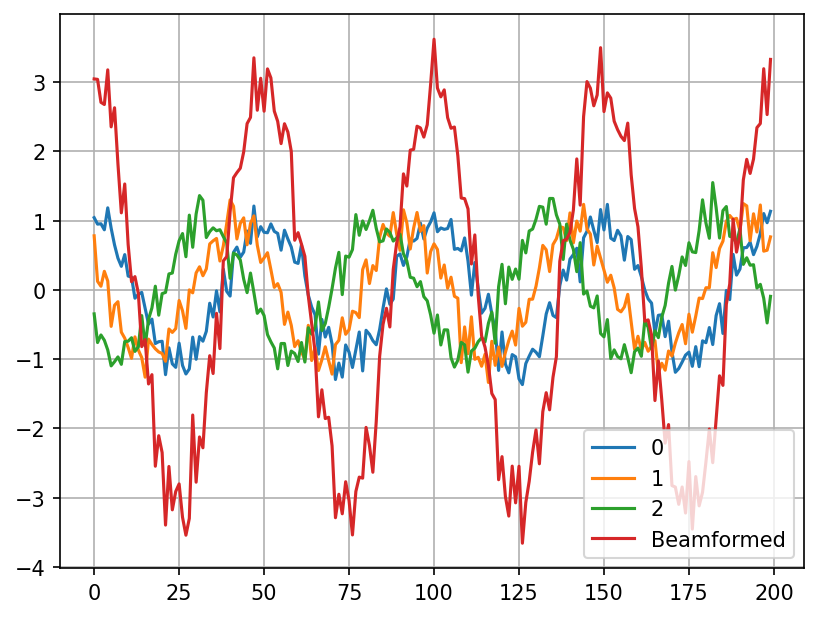

In [69]:
fig, ax = plt.subplots(dpi=150)

ax.plot(X[0, :200].squeeze().real, label="0")
ax.plot(X[1, :200].squeeze().real, label="1")
ax.plot(X[2, :200].squeeze().real, label="2")
ax.plot(y[:200].real, label="Beamformed")
ax.grid()
ax.legend()

19.999999999997737


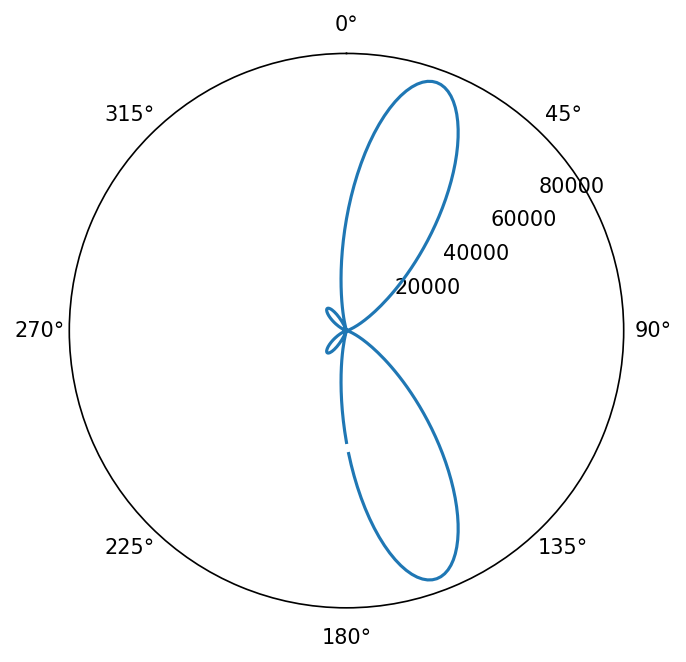

In [82]:
thetas, powers = beamforming.ula_doa(x, Nr, theta)
print(thetas[np.argmax(powers)]*180/np.pi)

fig, ax = plt.subplots(dpi=150, subplot_kw={"projection": "polar"})
# ax.plot(thetas*180/np.pi, powers)
ax.plot(thetas, powers)
ax.set_theta_zero_location('N') # make 0 degrees point up
ax.set_theta_direction(-1) # increase clockwise
ax.set_rlabel_position(55)  # Move grid labels away from other labels
ax.grid()